<a href="https://colab.research.google.com/github/ShubhamP1028/Project-ADITI/blob/main/SNN_using_LIF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="align:center"></h1>
<div align="center">
<h1><b><u>Project A.D.I.T.I.</b></u></h1>
</div>

In [2]:
# pull dataset from github repo
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 35.79 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.


In [3]:
color_dataset = "/content/PlantVillage-Dataset/raw/color"

segmented_dataset = "/content/PlantVillage-Dataset/raw/segmented"

In [4]:
# we'll train model on color or segmented but basd on that if segmented performs bettr we'll need to process color to segmented image

In [5]:
!pip install snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 8.3 MB/s eta 0:00:00


In [6]:
import torch
import torch.nn as nn
import snntorch
from snntorch import spikeplot as splt
from snntorch import functional as SF
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

print(f"snntorch version: {snntorch.__version__}")
print(f"torch version: {torch.__version__}")

snntorch version: 0.9.4
torch version: 2.10.0+cu128


# Task
Build a Spiking Neural Network (SNN) using the Leaky Integrate-and-Fire (LIF) neuron model from `snntorch` to classify plant diseases using the images from the "PlantVillage-Dataset" located at "/content/PlantVillage-Dataset/raw/color". The process includes verifying the dataset path, performing data exploration and preprocessing, implementing a custom SNN architecture with convolutional layers and LIF neurons, and evaluating the model's performance with accuracy plots and a confusion matrix.

## Verify and Locate Dataset

### Subtask:
Confirm the presence of the cloned PlantVillage-Dataset and identify the exact directory path for the color images.


**Reasoning**:
I will explore the directory structure of the cloned repository using glob to accurately locate the 'color' dataset path and store it in `final_color_path` as required by the instructions.



In [7]:
import os
import glob

# 1. Define base repository path
base_repo = "/content/PlantVillage-Dataset"

# 2. Use glob for recursive search for 'color' folder
# 3. Search pattern to look for any folder named 'color' within the repo
search_pattern = os.path.join(base_repo, '**', 'color')
found_paths = [p for p in glob.glob(search_pattern, recursive=True) if os.path.isdir(p)]

if found_paths:
    # 4. Store discovered path in final_color_path
    final_color_path = found_paths[0]

    # 5. Print and verify existence
    print(f"Final color path: {final_color_path}")
    print(f"Path exists: {os.path.exists(final_color_path)}")

    # 6. List subdirectories to confirm classes
    classes = [d for d in os.listdir(final_color_path) if os.path.isdir(os.path.join(final_color_path, d))]
    print(f"Found {len(classes)} classes.")
    print("Class samples:", classes[:5])
else:
    print("Error: 'color' directory not found. Please ensure the repository was cloned correctly.")
    final_color_path = None

Final color path: /content/PlantVillage-Dataset/raw/color
Path exists: True
Found 38 classes.
Class samples: ['Strawberry___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Late_blight', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Peach___healthy']


## Data Exploration and Analysis

### Subtask:
Analyze the class distribution and visualize sample images from the located PlantVillage color dataset to prepare for preprocessing.


**Reasoning**:
I will calculate the class distribution by counting image files in the verified 'final_color_path', visualize the distribution with a bar chart, and display random sample images with their dimensions as requested.



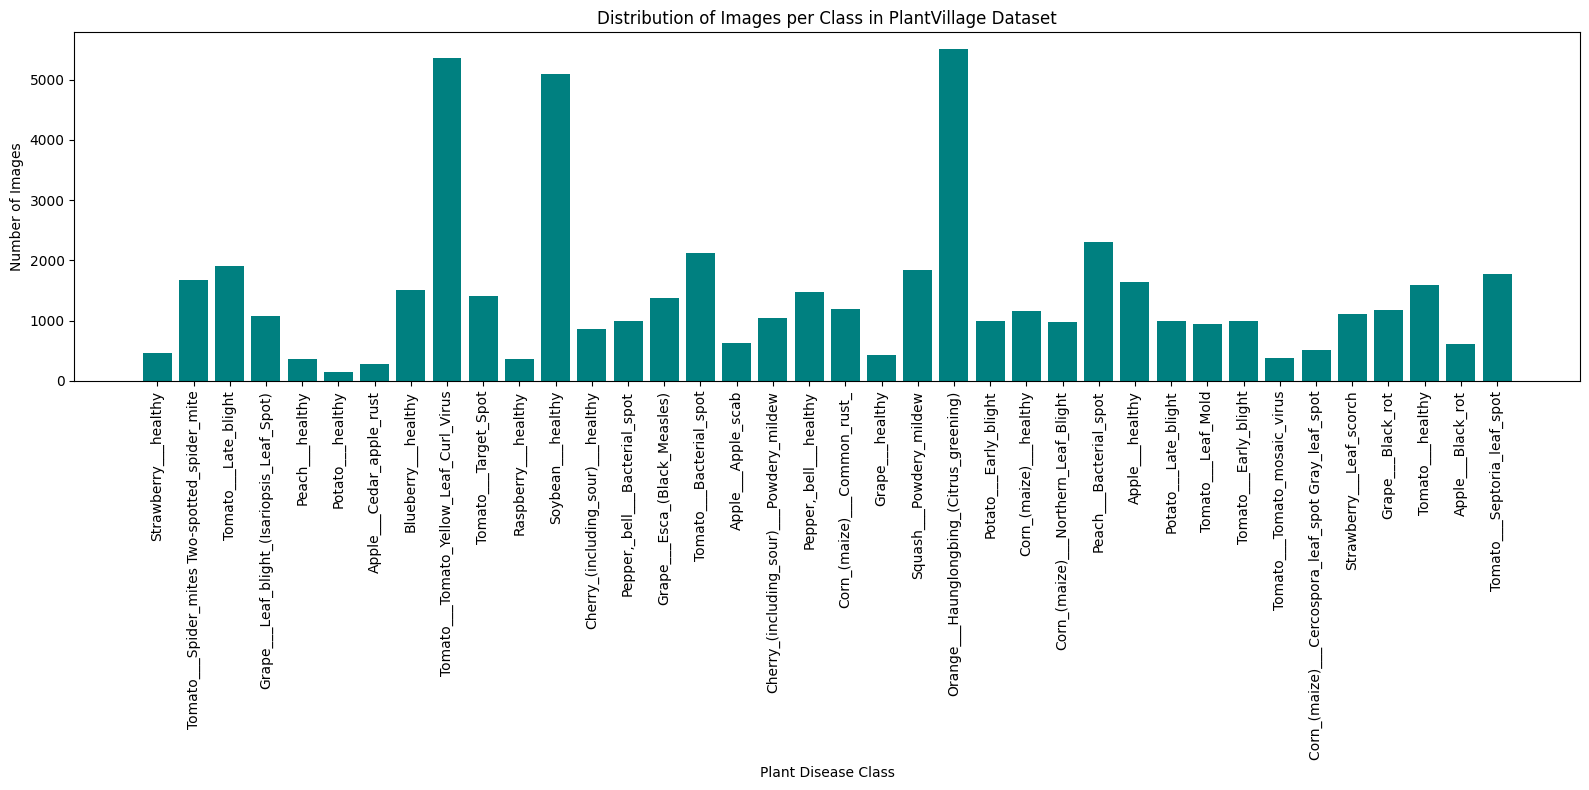

Sample 1 - Class: Apple___Apple_scab, Width: 256, Height: 256
Sample 2 - Class: Pepper,_bell___healthy, Width: 256, Height: 256
Sample 3 - Class: Pepper,_bell___Bacterial_spot, Width: 256, Height: 256


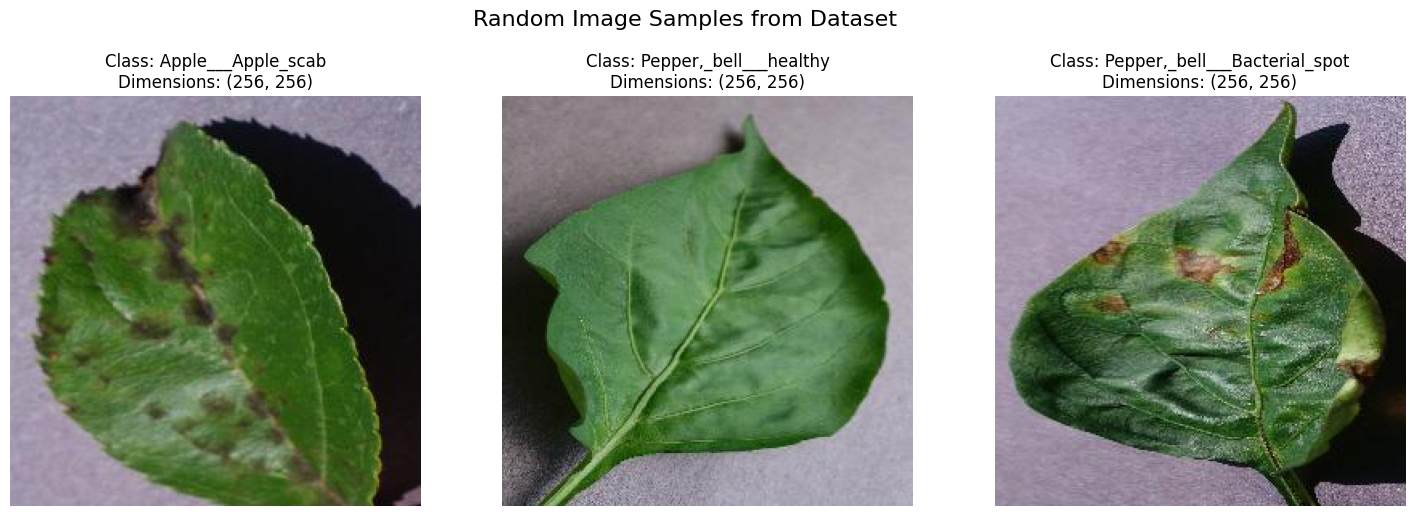

In [8]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# 1 & 2. Count images in each class folder from final_color_path
class_distribution = {}
classes = [d for d in os.listdir(final_color_path) if os.path.isdir(os.path.join(final_color_path, d))]

for cls in classes:
    cls_dir = os.path.join(final_color_path, cls)
    # Counting common image formats
    num_images = len([f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    class_distribution[cls] = num_images

# 3. Create a bar chart for class distribution
plt.figure(figsize=(16, 8))
plt.bar(class_distribution.keys(), class_distribution.values(), color='teal')
plt.xticks(rotation=90)
plt.xlabel('Plant Disease Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Class in PlantVillage Dataset')
plt.tight_layout()
plt.show()

# 4 & 5. Select, display random images and print dimensions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i in range(3):
    random_cls = random.choice(classes)
    cls_dir = os.path.join(final_color_path, random_cls)
    img_name = random.choice([f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    img_path = os.path.join(cls_dir, img_name)

    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"Class: {random_cls}\nDimensions: {img.size}")
    axes[i].axis('off')

    print(f"Sample {i+1} - Class: {random_cls}, Width: {img.width}, Height: {img.height}")

plt.suptitle('Random Image Samples from Dataset', fontsize=16)
plt.show()

## Data Preprocessing and Loading

### Subtask:
Define PyTorch transforms for resizing, normalization, and data augmentation. Create DataLoader objects for the training and validation sets using the verified path.


**Reasoning**:
I will import the required PyTorch and torchvision modules, define the image transformations for resizing and normalization, and create the DataLoaders for the training and validation splits as specified.



In [9]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import torch

# 2. Define transforms (resizing to 64x64, Tensor conversion, and ImageNet normalization)
data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Load dataset using ImageFolder
full_dataset = datasets.ImageFolder(root=final_color_path, transform=data_transforms)

# 4. Split into training (80%) and validation (20%) sets with a fixed seed
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

# 5. Create DataLoader instances
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 6. Print verification details
print(f"Total images in dataset: {len(full_dataset)}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Number of classes: {len(full_dataset.classes)}")

Total images in dataset: 54305
Training samples: 43444
Validation samples: 10861
Number of classes: 38


# Task
Build a Spiking Neural Network (SNN) using the Leaky Integrate-and-Fire (LIF) neuron model from `snntorch` to classify plant diseases using the images from the "PlantVillage-Dataset" located at "/content/PlantVillage-Dataset/raw/color". The project involves defining a custom SNN architecture featuring convolutional layers, pooling layers, and flatten layers integrated with LIF neurons. You must then train the model using a suitable optimizer and loss function, and evaluate its performance through accuracy plots and a confusion matrix to summarize the effectiveness of the LIF mechanism for this classification task.

## Define LIF-based SNN Architecture

### Subtask:
Implement a custom SNN class featuring convolutional layers, pooling layers, and flatten layers integrated with Leaky Integrate-and-Fire (LIF) neurons from `snntorch`.


**Reasoning**:
I will define the SNN class using snntorch's Leaky Integrate-and-Fire (LIF) neurons, incorporating convolutional, pooling, and linear layers as specified in the instructions.



In [10]:
import torch
import torch.nn as nn
import snntorch
from snntorch import surrogate
from snntorch import Leaky

# 2. Define a class named SNN that inherits from nn.Module
class SNN(nn.Module):
    def __init__(self, num_classes=38, beta=0.9, num_steps=25):
        super(SNN, self).__init__()

        self.num_steps = num_steps
        spike_grad = surrogate.fast_sigmoid(slope=25)

        # 3 & 4. Define architecture with Conv, MaxPool, Flatten, and Linear layers with LIF neurons
        # First Convolutional Block
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2)
        self.lif1 = snntorch.Leaky(beta=beta, spike_grad=spike_grad)

        # Second Convolutional Block
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2)
        self.lif2 = snntorch.Leaky(beta=beta, spike_grad=spike_grad)

        # Flatten and Fully Connected
        self.flatten = nn.Flatten()
        # Input features for Linear: (64-5+1=60)/2=30; (30-5+1=26)/2=13 -> 32*13*13 = 5408
        self.fc1 = nn.Linear(32 * 13 * 13, num_classes)
        self.lif3 = snntorch.Leaky(beta=beta, spike_grad=spike_grad)

    # 5. Implement the forward method to handle temporal dynamics
    def forward(self, x):
        # Initialize hidden states (membrane potentials)
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        # Record the final layer spikes
        spk3_rec = []
        mem3_rec = []

        # Iterate through fixed number of time steps
        for step in range(self.num_steps):
            cur1 = self.pool1(self.conv1(x))
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.pool2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.fc1(self.flatten(spk2))
            spk3, mem3 = self.lif3(cur3, mem3)

            spk3_rec.append(spk3)
            mem3_rec.append(mem3)

        # 6. Return the accumulated spikes and membrane potentials
        return torch.stack(spk3_rec, dim=0), torch.stack(mem3_rec, dim=0)

# Instantiate model and print summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SNN().to(device)
print(model)

SNN(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif1): Leaky()
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif2): Leaky()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=5408, out_features=38, bias=True)
  (lif3): Leaky()
)


## Training and Evaluation

### Subtask:
Train the LIF-based SNN using a cross-entropy loss and an optimizer, then evaluate the performance using accuracy metrics and a confusion matrix.


**Reasoning**:
I will define the training loop, optimizer, and loss function for the SNN, then execute the training and validation process, followed by plotting the metrics and confusion matrix as requested.



Epoch [1/5], Step [0/679], Loss: 4.9267
Epoch [1/5], Step [100/679], Loss: 2.7876
Epoch [1/5], Step [200/679], Loss: 1.9777
Epoch [1/5], Step [300/679], Loss: 2.2281
Epoch [1/5], Step [400/679], Loss: 1.5945
Epoch [1/5], Step [500/679], Loss: 1.4824
Epoch [1/5], Step [600/679], Loss: 1.3538
Epoch [1/5] completed. Validation Accuracy: 66.05%
Epoch [2/5], Step [0/679], Loss: 1.6112
Epoch [2/5], Step [100/679], Loss: 1.4278
Epoch [2/5], Step [200/679], Loss: 1.2705
Epoch [2/5], Step [300/679], Loss: 0.7305
Epoch [2/5], Step [400/679], Loss: 1.2942
Epoch [2/5], Step [500/679], Loss: 0.8139
Epoch [2/5], Step [600/679], Loss: 0.9864
Epoch [2/5] completed. Validation Accuracy: 71.93%
Epoch [3/5], Step [0/679], Loss: 0.9419
Epoch [3/5], Step [100/679], Loss: 0.6886
Epoch [3/5], Step [200/679], Loss: 0.9362
Epoch [3/5], Step [300/679], Loss: 0.9531
Epoch [3/5], Step [400/679], Loss: 1.3578
Epoch [3/5], Step [500/679], Loss: 0.6141
Epoch [3/5], Step [600/679], Loss: 0.5928
Epoch [3/5] completed.

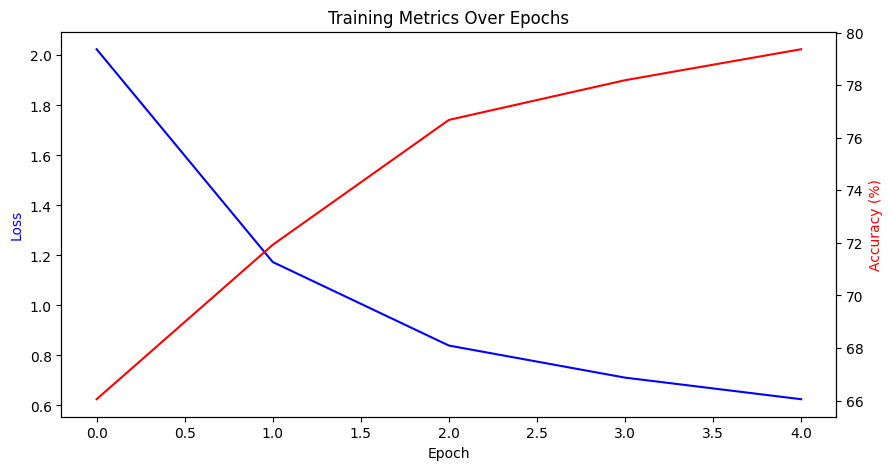

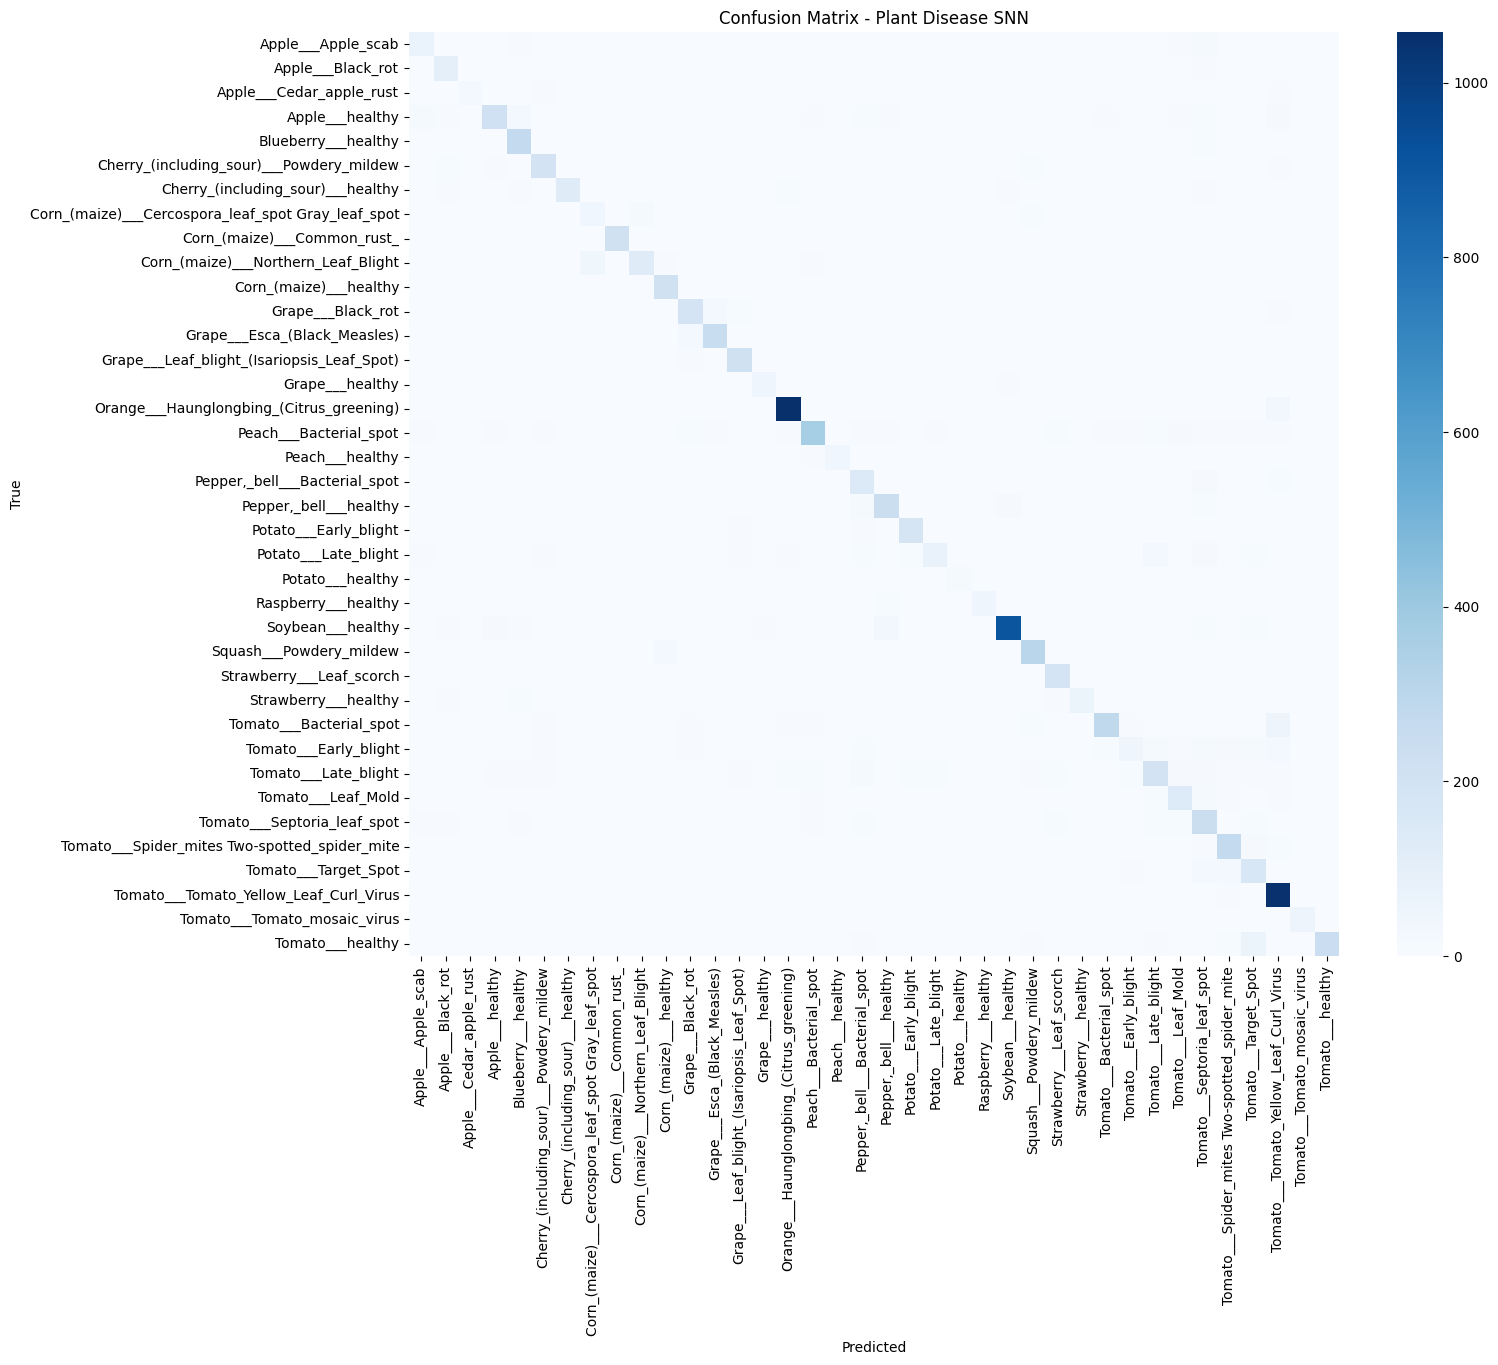

In [11]:
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Define loss function and optimizer
loss_fn = SF.ce_count_loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5
train_loss_hist = []
val_acc_hist = []

# 2 & 3. Training and Validation Loop
for epoch in range(num_epochs):
    model.train()
    avg_loss = 0
    for i, (data, targets) in enumerate(train_loader):
        data, targets = data.to(device), targets.to(device)

        # Forward pass
        spk_rec, mem_rec = model(data)

        # Loss calculation (using spike counts)
        loss_val = loss_fn(spk_rec, targets)

        # Gradient descent
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        avg_loss += loss_val.item()
        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i}/{len(train_loader)}], Loss: {loss_val.item():.4f}")

    train_loss_hist.append(avg_loss / len(train_loader))

    # Validation accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, targets in val_loader:
            data, targets = data.to(device), targets.to(device)
            spk_rec, _ = model(data)
            _, predicted = spk_rec.sum(dim=0).max(1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    val_acc = 100 * correct / total
    val_acc_hist.append(val_acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] completed. Validation Accuracy: {val_acc:.2f}%")

# 4. Plot Training Loss and Validation Accuracy
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(train_loss_hist, 'b-', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='b')
ax2 = ax1.twinx()
ax2.plot(val_acc_hist, 'r-', label='Val Acc')
ax2.set_ylabel('Accuracy (%)', color='r')
plt.title('Training Metrics Over Epochs')
plt.show()

# 5. Confusion Matrix
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for data, targets in val_loader:
        data, targets = data.to(device), targets.to(device)
        spk_rec, _ = model(data)
        _, predicted = spk_rec.sum(dim=0).max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(targets.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Plant Disease SNN')
plt.xticks(rotation=90)
plt.show()